# Plot the model-generated growth curves for the immunocompetent mice on top of the experimental data

This file generates Figure 6 in the main text and Supplementary Table S3.

It requires the growth data, config file, and minimum/maximum curve data (output of ``Figure_6_helper.py``) as input and will save the figures to the path if specified (change file paths below as needed).

The code will plot the true growth curves for each admixture and the ranges of the curves predicted by specified parameters in the file. The file is currently set up to reproduce Figures 6, plotting estimates for each group of parameters estimated for the B6 (immunocompetent) mice.

Note: You must run ``Figure_6_helper.py`` prior to this code in order to get the minimum/maximum curve data and extinction time distributions!

## Prep

Load needed packages

In [2]:
%matplotlib widget
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from estimator import Estimator

Close any figures from previous runs

In [ ]:
plt.close("all")

## Define data and user-input parameters

Define the config file, minimum/maximum curve files, and save files

In [3]:
config = "config_tcell.json"
b6_dir = "../min_max_curve_results/"
b6_save_file = "figures/Figure6_{}.svg" # Set to None if you don't want to save the figure

Define the groups to plot and the titles to use for the plots

In [4]:
groups_b6 = ["Grp. A1 B6 (100% C1)", "Grp. A2 B6 (80% C1; 20% C11)", "Grp. A3 B6 (50% C1; 50% C11)", "Grp. A4 B6 (20% C1; 80% C11)", "Grp. A5 B6 (100% C11)"]
titles = ["100% Proliferative", "80% Proliferative\n20% Invasive", "50% Proliferative\n50% Invasive", "20% Proliferative\n80% Invasive", "100% Invasive"]

Create an Estimator object from the config file

In [5]:
es = Estimator(config)

## Functions

Function to run the model

In [6]:
def run_model(es, init, g1, g11, k, m, p, a, f, l, end_time):
    sol = es.run_before_t(init, g1, g11, k, m, p, end_time)
    t1 = sol[3][-1]
    sol = es.run_incr_t(sol, g1, g11, k, m, p, a, f, l, end_time)
    t2 = sol[3][-1]
    sol = es.run_dec_t(sol, g1, g11, k, m, p, a, f, l, end_time) 
    return sol, t1, t2

Function to plot the B6 data and predictions. Shows the plot in the notebook and saves to b6_save_file if set.

@param r_group : the parameter group to plot (1a = 1, 1b = 2, 2a = 3, 2b = 4)

@param time_range : list of two values where first value is the minimum time to plot and second value is the maximum time to plot

@param t_init : the initial size of the T cell population

@param min_max_curves_r : dictionary containing the minimum and maximum curve information for each mouse group in the parameter group to plot. See below for dictionary generation from minimun/maximum curve files.

@param g11 : growth rate for C11 (invasive) subclone

In [8]:
def plot_b6(r_group, time_range, t_init, min_max_curves_r, g11):
    # Define the maximum value of the y-axis to be 5 larger than the maximum value across all B6 groups
    ylim = es.growth_df[es.growth_df["group"].isin(groups_b6)]["size"].max()+3

    # Change figure size at the last part of this line if needed. First value is width, second value is height.
    fig, axes = plt.subplots(nrows=1, ncols=5, sharex=True, sharey=True, figsize=(9.5,3.5))
    
    # Plot mouse grouns A1, A2, A3, and A4, which have ranges
    x = [i*0.01 for i in range(len(min_max_curves_r["A1"]["c1"][0]))]
    for i in range(4):

        # Extract the data for that group
        group_df = es.growth_df[es.growth_df["group"] == groups_b6[i]]
        # For each mouse in that group, plot its growth on the group-specific plot
        for mid in group_df["id"].unique():
            axes[i].plot(group_df[group_df["id"]==mid]["day"], group_df[group_df["id"]==mid]["size"], color="black", linewidth=1)
        # Annotate the group-specific plot
        axes[i].set(title=titles[i], ylim=[-1, max(es.growth_df["size"])+10], xlabel="Day", ylabel="scaled size")
        
        axes[i].fill_between(x=x, y1=min_max_curves_r[m_groups[i]]["c1"][1], y2=min_max_curves_r[m_groups[i]]["c1"][0], color="orange", alpha=0.75)
        axes[i].fill_between(x=x, y1=min_max_curves_r[m_groups[i]]["c11"][1], y2=min_max_curves_r[m_groups[i]]["c11"][0], color="blue", alpha=0.75)

        axes[i].set(title=titles[i], ylim=[-1, ylim])

    # Plot A5 (plotted separately because it doesn't have a range)
    # Extract the data for that group
    group_df = es.growth_df[es.growth_df["group"] == groups_b6[4]]
    # For each mouse in that group, plot its growth on the group-specific plot
    for mid in group_df["id"].unique():
        axes[4].plot(group_df[group_df["id"]==mid]["day"], group_df[group_df["id"]==mid]["size"], color="black", linewidth=1)
    # Annotate the group-specific plot
    axes[4].set(title=titles[4], ylim=[-1, max(es.growth_df["size"])+10], xlabel="Day", ylabel="scaled size")
    init = [0, 1, t_init]
    
    # Run the model -- A5 only depends on g11
    sol, t1, t2 = run_model(es, init, 0, g11, 0, 0, 0, 0, 0, 1, time_range[1])     
    axes[4].plot(sol[3], sol[0], color="orange", label="C1")
    axes[4].plot(sol[3], sol[1], color="blue", label="C11")

    # Annotate the group-specific plot            
    axes[4].set(title=titles[i], ylim=[-1, ylim])
        
    # Annotate the whole plot
    plt.ylim([-1, ylim])
    plt.suptitle("Group {}".format(r))
    plt.tight_layout()

    if b6_save_file:
        plt.savefig(b6_save_file.format(r_group))

    # Show the figure
    plt.show()

## Load minimum/maximum data

In [7]:
# Load the files
r_groups = [1, 2, 3, 4]
m_groups = ["A1", "A2", "A3", "A4"]

min_max_curves = {}

for r in r_groups:
    if not r in min_max_curves.keys(): min_max_curves[r] = {}
    for m in m_groups:
        if not m in min_max_curves[r].keys(): min_max_curves[r][m] = {}
        for c in ["c1", "c11"]:
            x_min = np.loadtxt("{}/{}_{}_min_{}.csv".format(b6_dir, r, m, c), delimiter=",")
            x_max = np.loadtxt("{}/{}_{}_max_{}.csv".format(b6_dir, r, m, c), delimiter=",")
            min_max_curves[r][m][c] = [x_min, x_max]

## Plot

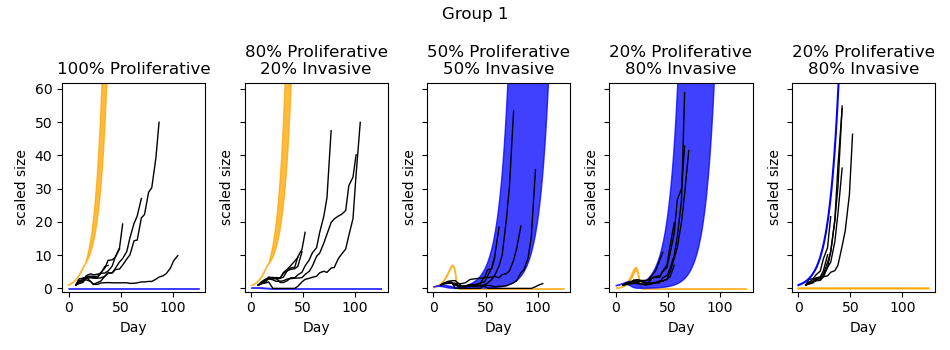

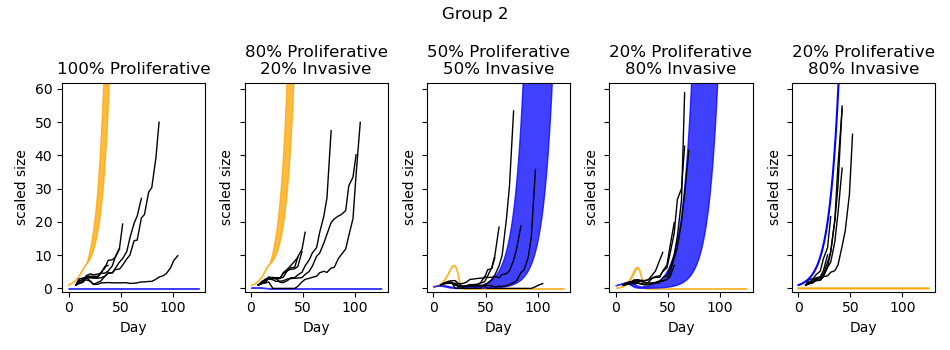

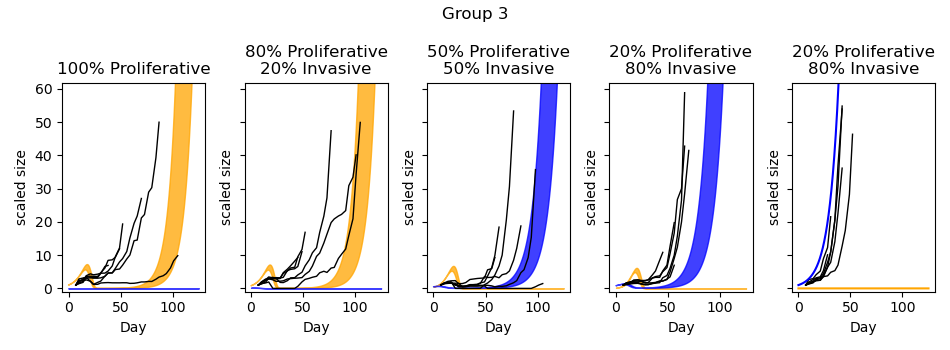

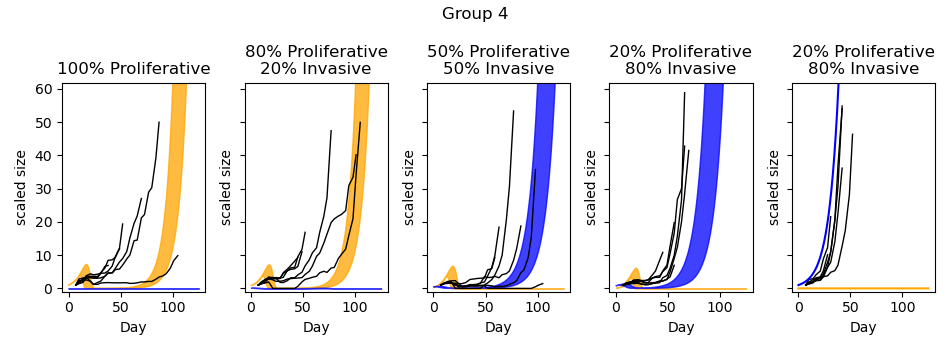

In [8]:
g11 = 0.107
t_init = 0.001
time_range = [0, 125]

# Loop through the groups and plot each
for r in r_groups:
    # Plot data and model-generated curves
    plot_b6(r, time_range, t_init, min_max_curves[r], g11)

## Extinction time distribution information

This loads the extinction time distribution files saved from ``Figure_6_helper.py`` and prints the median values for each parameter group. This is the data in Supplementary Table 3.

Load the data files

In [13]:
# Load the files
r_groups = [1, 2, 3, 4]
m_groups = ["A2", "A3", "A4"]

min_max_dists = {}

for r in r_groups:
    if not r in min_max_dists.keys(): min_max_dists[r] = {}
    for m in m_groups:
        dist = np.loadtxt("../min_max_dist/{}_{}.csv".format(r, m), delimiter=",")
        min_max_dists[r][m] = dist

Calculate the medians and print

In [14]:
medians = []
for r in r_groups:
    r_medians = []
    for m in m_groups:
        r_medians += [np.median([min_max_dists[r][m]])]
    medians += [[r] + r_medians]
medians = pd.DataFrame(medians, columns=["group"]+m_groups)
medians